In [56]:
# kegg
import requests
import pandas as pd
from io import StringIO # treat string as file-like object
import os
import time
from tqdm import tqdm

# entry, relation
import xml.etree.ElementTree as ET

# vis
import matplotlib.pyplot as plt
import seaborn as sns

# ids
import re



In [ ]:
def kegg_list(database:str):
    response = requests.get(f'https://rest.kegg.jp/list/{database}')
    df = pd.read_csv(StringIO(response.text), sep='\t', header=None, names=['entry', 'name'])
    return df

def kegg_get_kgml(dbentries:str, output_dir:str, verbose=True):
    # create output folder if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Define the URL of the API endpoint or XML resource
    url = f'https://rest.kegg.jp/get/{dbentries}/kgml'

    # Send the API request
    response = requests.get(url)

    # Check if the request was successful (status code 200)
    if response.status_code == 200:
        # Save the XML content to a file
        with open(f'./{output_dir}/{dbentries}_kgml.xml', 'wb') as file:
            file.write(response.content)
        if verbose == True:
            print(f'{dbentries} XML file downloaded successfully!')
    elif verbose == True:
        print(f'Failed to download {dbentries} XML file. Status code: {response.status_code}')

def kegg_batch_download(database:str, output_dir:str='./out/kgml/', delay=0.5):
    # get download list
    database_list = kegg_list(database)

    # download entries from list
    for entry in tqdm(database_list['entry']):
        kegg_get_kgml(dbentries=entry, output_dir=output_dir, verbose=False)
        time.sleep(delay)

In [30]:
# list pathways
kegg_list('pathway/hsa')

,entry,name
0,hsa01100,Metabolic pathways - Homo sapiens (human)
1,hsa01200,Carbon metabolism - Homo sapiens (human)
2,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...
3,hsa01212,Fatty acid metabolism - Homo sapiens (human)
4,hsa01230,Biosynthesis of amino acids - Homo sapiens (hu...
...,...,...
360,hsa04934,Cushing syndrome - Homo sapiens (human)
361,hsa01521,EGFR tyrosine kinase inhibitor resistance - Ho...
362,hsa01524,Platinum drug resistance - Homo sapiens (human)
363,hsa01523,Antifolate resistance - Homo sapiens (human)


In [27]:
# download pathways
kegg_batch_download('pathway/hsa')

100%|██████████| 365/365 [09:30<00:00,  1.56s/it]


---

In [46]:
def parse_kgml_entry(kgml_dir:str):
    root = ET.parse(kgml_dir).getroot()

    # Extract pathway attributes
    pathway_name = root.attrib.get('name', '')
    pathway_title = root.attrib.get('title', '')

    # Prepare a list to store entry data
    data = []

    # Iterate over each <entry> in the <pathway>
    for entry in root.findall('entry'):
        entry_dict = {
            'pathway_name': pathway_name,
            'pathway_title': pathway_title,
            'id': entry.attrib.get('id', ''),
            'name': entry.attrib.get('name', ''),
            'type': entry.attrib.get('type', ''),
            'reaction': entry.attrib.get('reaction', '')
        }

        data.append(entry_dict)

    return data

def parse_kgml_relation(kgml_dir:str):
    root = ET.parse(kgml_dir).getroot()

    # Extract pathway attributes
    pathway_name = root.attrib.get('name', '')
    pathway_title = root.attrib.get('title', '')

    # Prepare a list to store entry data
    data = []

    # Iterate over each <relation> in the <pathway>
    for relation in root.findall('relation'):

        entry1 = relation.attrib.get('entry1', '')
        entry2 = relation.attrib.get('entry2', '')
        relation_type = relation.attrib.get('type', '')

        # Check if there are any <subtype> elements
        subtypes = relation.findall('subtype')

        # If no <subtype>, add a row with None values for subtype fields
        if not subtypes:
            data.append({
                'pathway_name': pathway_name,
                'pathway_title': pathway_title,
                'id1': entry1,
                'id2': entry2,
                'relation_type': relation_type,
                'subtype_name': None,
                'subtype_value': None
            })

        # If there are subtypes, add a row for each subtype
        else:
            for subtype in subtypes:
                subtype_name = subtype.attrib.get('name', '')
                subtype_value = subtype.attrib.get('value', '')

                data.append({
                    'pathway_name': pathway_name,
                    'pathway_title': pathway_title,
                    'id1': entry1,
                    'id2': entry2,
                    'relation_type': relation_type,
                    'subtype_name': subtype_name,
                    'subtype_value': subtype_value
                })

    return data

def batch_parse_kgml(batch_func, input_dir:str = './out/kgml/'):

    kgmls = []

    # Iterate over all files in the given folder
    for filename in tqdm(os.listdir(input_dir)):
        # Check if the file has a .xml extension
        kgml_dir = os.path.join(input_dir, filename)
        kgml = batch_func(kgml_dir)
        kgmls.append(kgml)

    flattened_kgmls = [entry for kgml in kgmls for entry in kgml]

    return flattened_kgmls

    


In [47]:
entry = pd.DataFrame(batch_parse_kgml(batch_func=parse_kgml_entry))
entry

100%|██████████| 365/365 [00:00<00:00, 650.86it/s]


,pathway_name,pathway_title,id,name,type,reaction
0,path:hsa04975,Fat digestion and absorption,19,path:hsa04975,map,
1,path:hsa04975,Fat digestion and absorption,22,path:hsa04530,map,
2,path:hsa04975,Fat digestion and absorption,43,path:hsa04972,map,
3,path:hsa04975,Fat digestion and absorption,46,hsa:64240,gene,
4,path:hsa04975,Fat digestion and absorption,47,hsa:64241,gene,
...,...,...,...,...,...,...
47627,path:hsa00190,Oxidative phosphorylation,262,ko:K24007,ortholog,
47628,path:hsa00190,Oxidative phosphorylation,109,hsa:100532726 hsa:107984365 hsa:126328 hsa:374...,gene,
47629,path:hsa00190,Oxidative phosphorylation,274,ko:K22468,ortholog,
47630,path:hsa00190,Oxidative phosphorylation,275,hsa:54205,gene,


In [48]:
relation = pd.DataFrame(batch_parse_kgml(batch_func=parse_kgml_relation))
relation

100%|██████████| 365/365 [00:00<00:00, 1134.84it/s]


,pathway_name,pathway_title,id1,id2,relation_type,subtype_name,subtype_value
0,path:hsa04975,Fat digestion and absorption,61,181,ECrel,compound,178
1,path:hsa04975,Fat digestion and absorption,181,63,ECrel,compound,174
2,path:hsa04975,Fat digestion and absorption,62,63,ECrel,compound,174
3,path:hsa04975,Fat digestion and absorption,228,229,PCrel,binding/association,---
4,path:hsa04975,Fat digestion and absorption,233,231,PCrel,binding/association,---
...,...,...,...,...,...,...,...
24352,path:hsa04922,Glucagon signaling pathway,77,139,PCrel,activation,-->
24353,path:hsa04922,Glucagon signaling pathway,139,80,PPrel,activation,-->
24354,path:hsa04922,Glucagon signaling pathway,139,80,PPrel,dephosphorylation,-p
24355,path:hsa00190,Oxidative phosphorylation,112,115,ECrel,compound,129


---

,pathway_name,pathway_title,id,name,type,reaction
3,path:hsa04975,Fat digestion and absorption,46,"(hsa:64240,)",gene,
4,path:hsa04975,Fat digestion and absorption,47,"(hsa:64241,)",gene,
5,path:hsa04975,Fat digestion and absorption,48,"(hsa:29881,)",gene,
6,path:hsa04975,Fat digestion and absorption,49,"(hsa:948,)",gene,
10,path:hsa04975,Fat digestion and absorption,53,"(hsa:338,)",gene,
...,...,...,...,...,...,...
47618,path:hsa00190,Oxidative phosphorylation,253,"(hsa:55967,)",gene,
47619,path:hsa00190,Oxidative phosphorylation,254,"(hsa:51079,)",gene,
47620,path:hsa00190,Oxidative phosphorylation,255,"(hsa:6389, hsa:6390, hsa:6391, hsa:6392)",gene,
47628,path:hsa00190,Oxidative phosphorylation,109,"(hsa:100532726, hsa:107984365, hsa:126328, hsa...",gene,


There is 8542 unique genes across 6451 unique gene groups.
Length of a gene group ranges from 1 to 412.


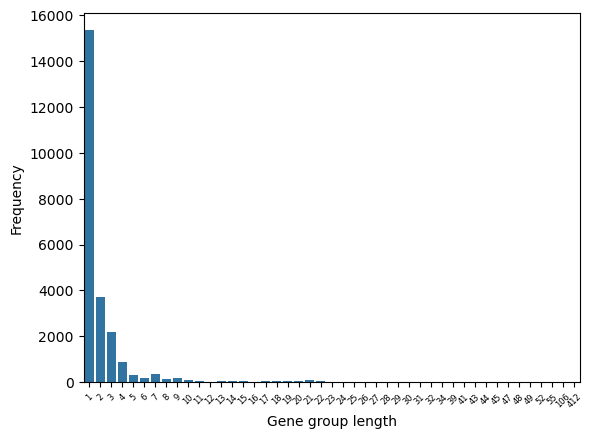

In [57]:
# cleaning entry -> entry_filt
entry_filt = entry[entry['type'] == 'gene'] # filter for type == gene (gene groups) 
entry_filt.loc[:, 'name'] = entry_filt['name'].str.split(' ') # split name (gene groups) into list (list of genes)
entry_filt.loc[:, 'name'] = entry_filt['name'].apply(lambda x: tuple(sorted(x))) # convert lists to sorted tuples
display(entry_filt)

# gene group summary stats
print(f'There is {len(set(gene for sublist in entry_filt['name'] for gene in sublist))} unique genes across {len(set(entry_filt['name']))} unique gene groups.')
print(f'Length of a gene group ranges from {min([len(i) for i in entry_filt['name']])} to {max([len(i) for i in entry_filt['name']])}.')

# visualizing distribution of gene group lengths
occurrences = [len(i) for i in entry_filt['name']]
occurences_dict = {item: occurrences.count(item) for item in set(occurrences)}
sns.barplot(occurences_dict)
plt.xlabel('Gene group length')
plt.ylabel('Frequency')
plt.xticks(rotation=45, fontsize=6)
plt.show()

---

In [62]:
def kegg_get_entry(dbentries='', output_dir='', verbose=True):
    # Create output folder if it doesn't exist
    if output_dir != '':
        os.makedirs(output_dir, exist_ok=True)

    # Define the URL of the API endpoint or XML resource
    url = f'https://rest.kegg.jp/get/{dbentries}'

    # Send the API request
    response = requests.get(url)

    # Check if the request was successful (status code 200)
    if response.status_code == 200:
        # Save the XML content to a file
        with open(f'./{output_dir}/{dbentries}.txt'.replace(':',''), 'wb') as file:
            file.write(response.content)
        # if verbose == True:
        #     print(f'{dbentries} TXT file downloaded successfully!')
    elif verbose == True:
        print(f'Failed to download {dbentries} TXT file. Status code: {response.status_code}')

In [64]:
# get unique genes
gene_list = entry_filt['name'].explode().unique().tolist()

# download entries
for entry in tqdm(gene_list):
    kegg_get_entry(dbentries=entry, output_dir='./out/entries/', verbose=True)
    # time.sleep(0.05)

  0%|          | 0/8542 [00:00<?, ?it/s]

100%|██████████| 8542/8542 [2:04:56<00:00,  1.14it/s]  


---

In [52]:
def parse_txt_entry(txt_dir:str):
    # open .txt file
    with open(txt_dir, 'r') as file:
        file_content = file.read()

    parsed_data = {}
    current_key = None

    for line in file_content.strip().splitlines(): 
        
        # check if the line starts with a key (no leading spaces)
        if not line.startswith(' '): 
            parts = line.split(maxsplit=1) # split on whitespace to separate key and value
            current_key = parts[0]
            value = parts[1] if len(parts) > 1 else '' 
            
            if current_key not in parsed_data: # initialize the key in the dictionary if it doesn't exist
                parsed_data[current_key] = []
            parsed_data[current_key].append(value)

        else: # if line is indented, it's a continuation of the last key
            parsed_data[current_key].append(line.strip())  # strip leading whitespace and add to the current key's values

    return parsed_data

def batch_parse_ids(input_dir:str = './out/entries/'):

    txt_entries = []

    for filename in tqdm(os.listdir(input_dir)):
        # format dir str
        txt_dir = os.path.join(input_dir, filename)

        # parse data
        parsed_data = parse_txt_entry(txt_dir)

        # get ids
        try:
            kegg = 'hsa:' + re.match(r'(\d+)', parsed_data['ENTRY'][0]).group(1)
        except:
            kegg = ''

        try:
            symbol = parsed_data['SYMBOL'][0].split(', ')[0]
        except:
            symbol = ''

        try:
            name = parsed_data['NAME'][0]
        except:
            name = ''

        try:
            ensembl = dict(entry.split(': ', 1) for entry in parsed_data['DBLINKS'])['Ensembl']
        except:
            ensembl = ''

        # format ids into dict
        ids = {
            'kegg': kegg,
            'symbol': symbol,
            'name': name,
            'ensembl': ensembl
        } 

        # append to list
        txt_entries.append(ids)

    return txt_entries        


In [53]:
ids = pd.DataFrame(batch_parse_ids())
ids

0it [00:00, ?it/s]


""
